
Core components
Component 	Points

An introduction that provides context and a clearly defined goal of the project (e.g. answer question X using data) 	1p
A component where data is extracted from some data source and/or loaded onto the Jupyter Notebook. The raw data needs to also be exported at this point and saved to the repository as a .csv or .json file, so that a reviewer can run and test the code with the saved data without needing an API key or manually loading the data from the source. E.g. have a cell where the data is exported, and a commented out code cell where the saved data can be imported. 	1p
A component where the loaded data is cleaned and transformed 	1p
A component where the cleaned data is analyzed visually and quantitatively (e.g. using statistics or machine learning) 	2p
A component where both the raw data and results can be exported (e.g. as a CSV) 	1p
A conclusion where the most interesting results and findings are described 	1p
Total 	7p
Additional requirements

In addition to the previous high-level requirements, the project must also include the following elements:
Component 	Points
Documentation describing how anyone can use your Jupyter Notebook (typically placed at the very beginning) 	0.5p
An embedded image that describes visually the data pipeline and what happens in the notebook. Think of this like something you would use when presenting your project to e.g. a coworker or manager who does not want to see the details or code itself. 	0.5p
A part where the Notebook connects to an API either for collecting data as the primary data source or as a supplementary data source, or e.g. for connecting to an LLM that is used for cleaning data or analyzing data 	2p
Total 	3p
Other Instructions
Code quality

Write your code so that it is pleasant to read and easy to understand. This includes:

    Use descriptive variable and function names.
    Add brief comments where the logic is not immediately obvious.
    Keep your notebook organized with clear separation between parts.
    Print out key information, using for example df.head(). To print a better looking DataFrame, consider also using display() instead of print().
    Divide the code into logical chunks. At minimum, use separate cells per part (e.g. extracting data in one cell, transforming it in another), and when relevant divide parts into multiple cells
    Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

    Labels for both axes
    A descriptive title
    Colors and a legend when relevant

Penalties

    -5 points if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a .env file and add .env to your .gitignore.
    -5 points if AI-generated (hallucinated) data is used instead of the actual dataset or data collected via the API. The project requires working with real data, not made-up values!
    -1 point if the Jupyter Notebook is overall messy and not structured well (e.g. if all code for all parts is within one cell, if the relevant outcomes are difficult to understand due to too much irrelevant printed output).



Dataset name and link

I selected the dataset “Wearable Health Devices Performance Analysis”:

Source: Kaggle
Dataset link: https://www.kaggle.com/datasets/pratyushpuri/wearable-health-devices-performance-analysis
Dataset Description

The dataset contains performance evaluations of wearable health devices collected between June 1, 2025 and June 26, 2025. It includes a total of 2,375 observations (rows) and 17 variables (17 columns).

The dataset covers major wearable technology brands such as Apple, Samsung, Garmin, Fitbit, Huawei, Amazfit, WHOOP, Oura, Polar, and Withings.

Devices are categorized into types such as smartwatches, fitness trackers, smart rings, fitness bands, and sports watches. The dataset covers the device technical specifications, performance metrics and user satisfaction ratings.

The variables in the dataset include:

Product information:
test date, device name, brand, model, category.
Market information:
price in USD and app ecosystem support (iOS, Android, Cross-platform)
Device specifications:
battery life hours, number of sensors, connectivity features (Bluetooth, WiFi, NFC, LTE), and water resistance features (e.g., IP68, 5ATM).
Performance metrics:
heart rate accuracy (%), step count accuracy (%), sleep tracking accuracy (%), GPS accuracy (meters)
User perception: user satisfaction rating (1–10 scale)
Overall evaluation: performance score (0–100), which represents a composite measure of device performance.
The aim of my project is to examine how device characteristics and price relate to both objective performance and subjective user satisfaction in wearable health devices.

More specifically, I will address several research questions:

To what extent does device price predict overall performance score?
Which device features (e.g., battery life, accuracy metrics, number of sensors) influence user satisfaction ratings?
Although the dataset is synthetic, it provides a useful basis for practicing statistical analysis and exploring patterns relevant to digital health wearables. In particular, this project connects to my Master's thesis on digital health/wellness wearable technologies, where I examine user perceptions (perceived value) of wearable devices through a survey experiment.

I will start with data cleaning and preprocessing (e.g., handling missing values, converting data types, etc.). Next, I will conduct exploratory data analysis (EDA) to understand the distribution of key variables (e.g., price, performance score, user satisfaction) and identify patterns across brands and device categories.

In [1]:
# connecting to the database file
import pandas as pd

df_wearables = pd.read_csv("wearable_health_devices_performance_upto_26june2025.csv")

# loading
df_wearables.head(10)

,Test_Date,Device_Name,Brand,Model,Category,Price_USD,Battery_Life_Hours,Heart_Rate_Accuracy_Percent,Step_Count_Accuracy_Percent,Sleep_Tracking_Accuracy_Percent,Water_Resistance_Rating,User_Satisfaction_Rating,GPS_Accuracy_Meters,Connectivity_Features,Health_Sensors_Count,App_Ecosystem_Support,Performance_Score
0,2025-06-01,Fitbit Inspire 4,Fitbit,Inspire 4,Fitness Tracker,141.74,129.9,89.69,93.03,78.91,3ATM,6.5,NaN,"Bluetooth, WiFi",5,Cross-platform,68.4
1,2025-06-01,Apple Watch SE 3,Apple,Watch SE 3,Smartwatch,834.64,26.5,95.92,98.20,79.76,IP68,8.3,4.9,"WiFi, Bluetooth, NFC",8,iOS,60.1
2,2025-06-01,Fitbit Versa 4,Fitbit,Versa 4,Sports Watch,145.34,161.2,92.24,96.81,74.49,IPX8,6.0,1.7,Bluetooth,7,Cross-platform,59.3
3,2025-06-01,Polar Vantage V3,Polar,Vantage V3,Smartwatch,349.53,69.4,96.77,95.56,78.06,IP68,8.0,3.2,"WiFi, Bluetooth, NFC, LTE",12,Cross-platform,61.0
4,2025-06-01,Samsung Galaxy Watch FE,Samsung,Galaxy Watch FE,Smartwatch,502.43,39.7,92.27,98.15,75.23,IPX8,8.3,1.6,"WiFi, Bluetooth, NFC, LTE",14,Android/iOS,61.2
5,2025-06-01,Garmin Forerunner 965,Garmin,Forerunner 965,Smartwatch,402.32,287.4,92.85,99.34,77.58,5ATM,8.1,2.3,"WiFi, Bluetooth, NFC, LTE",11,Cross-platform,63.6
6,2025-06-01,Withings ScanWatch 2,Withings,ScanWatch 2,Sports Watch,235.64,219.2,96.41,94.22,79.07,5ATM,7.2,3.4,Bluetooth,9,Cross-platform,61.3
7,2025-06-01,Garmin Fenix 8,Garmin,Fenix 8,Smartwatch,897.85,589.9,93.65,99.27,75.23,5ATM,9.0,4.6,"WiFi, Bluetooth, NFC",14,Cross-platform,63.3
8,2025-06-01,Samsung Galaxy Watch Ultra,Samsung,Galaxy Watch Ultra,Smartwatch,318.18,36.4,92.33,96.83,82.94,5ATM,8.2,3.7,"WiFi, Bluetooth, NFC, LTE",15,Android/iOS,60.6
9,2025-06-01,WHOOP 4.0,WHOOP,4.0,Fitness Band,30.00,120.7,91.48,94.79,73.71,IPX4,6.1,NaN,Bluetooth,3,Android/iOS,67.1


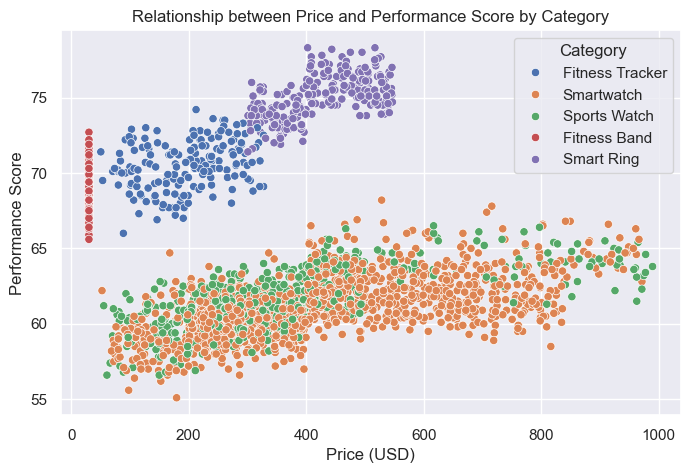

In [2]:
# scatterplot visualisation

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme() 

plt.figure(figsize=(8,5))
sns.scatterplot(data=df_wearables, x="Price_USD", y="Performance_Score", hue="Category")

plt.title("Relationship between Price and Performance Score by Category")
plt.xlabel("Price (USD)")



plt.ylabel("Performance Score")
plt.show()

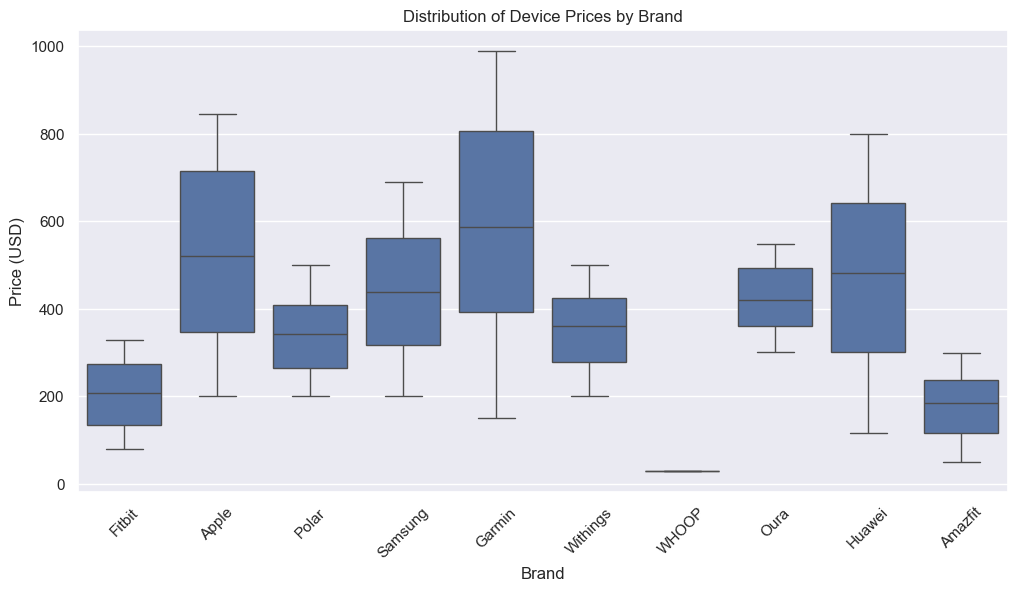

In [3]:
#boxplot comparing different brand  price distribution

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_wearables,
    x="Brand",
    y="Price_USD"
)

plt.title("Distribution of Device Prices by Brand")
plt.xlabel("Brand")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)
plt.show()

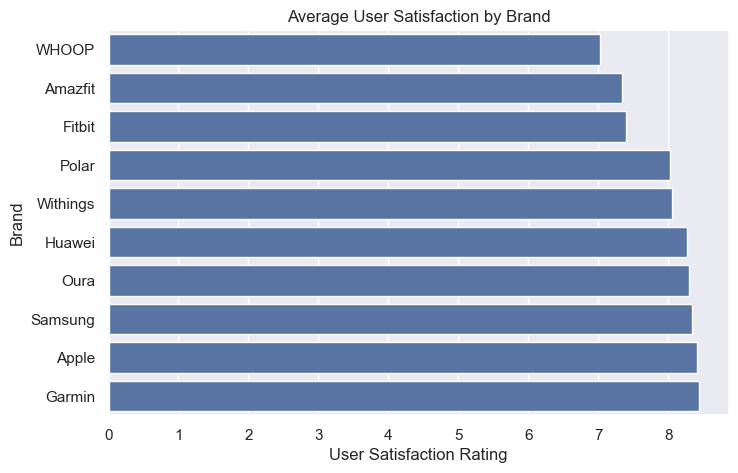

In [4]:
#correlation of satisfaction and the brand

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

brand_sat = df_wearables.groupby("Brand")["User_Satisfaction_Rating"].mean().sort_values()

sns.barplot(x=brand_sat.values, y=brand_sat.index)

plt.title("Average User Satisfaction by Brand")
plt.xlabel("User Satisfaction Rating")
plt.ylabel("Brand")
plt.show()